<a href="https://colab.research.google.com/github/utsabfdahal/ChattrGFinal/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

# Unzip into working directory
import zipfile

zip_path = "/content/drive/MyDrive/Datasetss.zip"  # Adjust if needed
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Inspect contents
!ls /content/Datasetss
!ls /content/Datasetss/images | head
!ls /content/Datasetss/masks | head


images	masks
1000.png
1001.png
1002.png
1003.png
1004.png
1005.png
1006.png
1007.png
1008.png
1009.png
1000.png
1001.png
1002.png
1003.png
1004.png
1005.png
1006.png
1007.png
1008.png
1009.png


In [4]:
import os
from PIL import Image as PilImage
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.transforms.functional as TF

In [5]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0.001, verbose=True):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_score = None
        self.counter = 0
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_score, model):
        score = val_score

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0


In [6]:
transforms1 = transforms.Compose([
    transforms.Resize((256, 256), interpolation=PilImage.NEAREST),  # Nearest neighbor for masks
    transforms.ToTensor(),
])


In [7]:
class BrainTumorDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, target_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.target_transform = target_transform

        image_files = sorted(os.listdir(images_dir))
        mask_files = sorted(os.listdir(masks_dir))

        # Only keep common filenames
        self.common_files = sorted(list(set(image_files) & set(mask_files)))

    def __len__(self):
        return len(self.common_files)

    def __getitem__(self, idx):
        filename = self.common_files[idx]
        img_path = os.path.join(self.images_dir, filename)
        mask_path = os.path.join(self.masks_dir, filename)

        image = PilImage.open(img_path).convert("RGB")
        mask = PilImage.open(mask_path).convert("L")

        # Ensure mask is binary (0 or 1)
        mask = mask.point(lambda x: 255 if x > 20 else 0)

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            mask = self.target_transform(mask)
            mask = (mask > 0.5).float()  # ensure binary

        return image, mask


In [8]:
dataset = BrainTumorDataset(
    images_dir="/content/Datasetss/images",
    masks_dir="/content/Datasetss/masks",
    transform = transforms1,
    target_transform = transforms1
)




In [9]:
total_data = len(dataset)
print(total_data)

3064


In [10]:
# Split into train/val
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4)

In [11]:
import torch.nn as nn
import torchvision.transforms.functional as TF
import torch.nn.functional as F

def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.enc1 = double_conv(in_channels, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.enc5 = double_conv(512, 1024)

        self.pool = nn.MaxPool2d(2)

        self.up1 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec1 = double_conv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec2 = double_conv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = double_conv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec4 = double_conv(128, 64)

        self.out = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))
        x4 = self.enc4(self.pool(x3))
        x5 = self.enc5(self.pool(x4))

        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.dec1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.dec2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.dec3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec4(x)

        return self.out(x)


In [12]:
model = UNet(in_channels=3, out_channels=1)


In [13]:
model = UNet().to("cuda" if torch.cuda.is_available() else "cpu")
device = next(model.parameters()).device

import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)



In [14]:
one_img_dataset = torch.utils.data.Subset(dataset, [0])
loader = DataLoader(one_img_dataset, batch_size=1)

for epoch in range(100):
    model.train()
    for image, mask in loader:
        image, mask = image.to(device), mask.to(device)
        pred = model(image)
        loss = criterion(pred, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 1, Loss: 0.7491
Epoch 2, Loss: 0.7161
Epoch 3, Loss: 0.6898
Epoch 4, Loss: 0.6657
Epoch 5, Loss: 0.6459
Epoch 6, Loss: 0.6297
Epoch 7, Loss: 0.6152
Epoch 8, Loss: 0.6013
Epoch 9, Loss: 0.5878
Epoch 10, Loss: 0.5751
Epoch 11, Loss: 0.5627
Epoch 12, Loss: 0.5507
Epoch 13, Loss: 0.5394
Epoch 14, Loss: 0.5289
Epoch 15, Loss: 0.5190
Epoch 16, Loss: 0.5091
Epoch 17, Loss: 0.4992
Epoch 18, Loss: 0.4896
Epoch 19, Loss: 0.4804
Epoch 20, Loss: 0.4712
Epoch 21, Loss: 0.4620
Epoch 22, Loss: 0.4527
Epoch 23, Loss: 0.4435
Epoch 24, Loss: 0.4344
Epoch 25, Loss: 0.4255
Epoch 26, Loss: 0.4171
Epoch 27, Loss: 0.4092
Epoch 28, Loss: 0.4016
Epoch 29, Loss: 0.3944
Epoch 30, Loss: 0.3878
Epoch 31, Loss: 0.3818
Epoch 32, Loss: 0.3765
Epoch 33, Loss: 0.3713
Epoch 34, Loss: 0.3672
Epoch 35, Loss: 0.3640
Epoch 36, Loss: 0.3600
Epoch 37, Loss: 0.3567
Epoch 38, Loss: 0.3536
Epoch 39, Loss: 0.3506
Epoch 40, Loss: 0.3479
Epoch 41, Loss: 0.3452
Epoch 42, Loss: 0.3427
Epoch 43, Loss: 0.3404
Epoch 44, Loss: 0.33

In [15]:
model.eval()
with torch.no_grad():
    image, mask = dataset[0]
    pred = torch.sigmoid(model(image.unsqueeze(0).to(device))).squeeze().cpu()




In [16]:
def dice_score(pred, target, threshold=0.5):
    pred = torch.sigmoid(pred) > threshold
    intersection = (pred & target.bool()).float().sum((1, 2, 3))
    union = pred.float().sum((1, 2, 3)) + target.float().sum((1, 2, 3))
    return (2. * intersection + 1e-6) / (union + 1e-6)

def train_one_epoch():
    model.train()
    total_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        preds = F.interpolate(preds, size=masks.shape[2:], mode='bilinear', align_corners=False)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def validate():
    model.eval()
    dice_scores = []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            preds = F.interpolate(preds, size=masks.shape[2:], mode='bilinear', align_corners=False)
            dice = dice_score(preds, masks)
            dice_scores.extend(dice.cpu().numpy())
    return sum(dice_scores) / len(dice_scores)


In [17]:
early_stopping = EarlyStopping(patience=7, delta=0.001, verbose=True)


In [18]:
for epoch in range(5):  # increase to 30+
    train_loss = train_one_epoch()
    val_dice = validate()
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Dice = {val_dice:.4f}")


    # Call early stopping
    early_stopping(val_dice, model)

    if early_stopping.early_stop:
        print("⏹️ Early stopping triggered.")
        break


Epoch 1: Train Loss = 0.2146, Val Dice = 0.4240
Epoch 2: Train Loss = 0.1040, Val Dice = 0.3429
EarlyStopping counter: 1/7
Epoch 3: Train Loss = 0.0637, Val Dice = 0.5731
Epoch 4: Train Loss = 0.0447, Val Dice = 0.4447
EarlyStopping counter: 1/7
Epoch 5: Train Loss = 0.0346, Val Dice = 0.6527


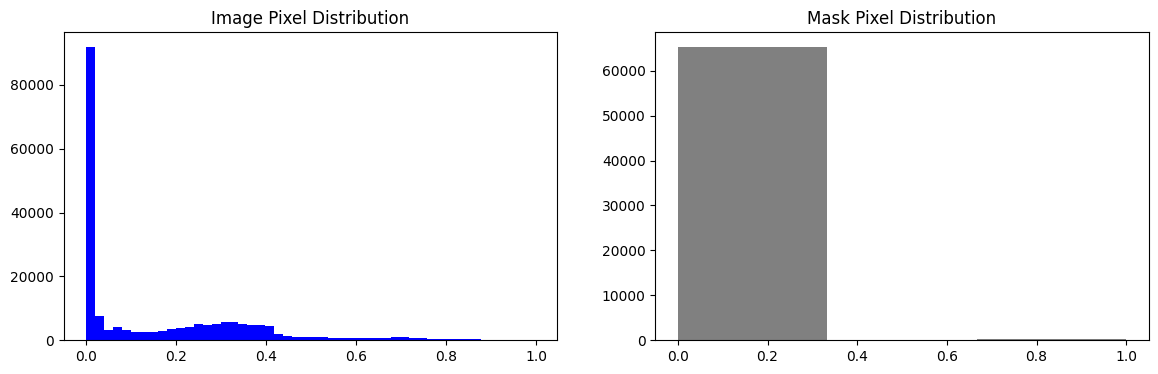

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize histogram of a sample batch
for images, masks in train_loader:
    img = images[1].permute(1, 2, 0).numpy()
    mask = masks[1].squeeze().numpy()

    plt.figure(figsize=(14, 4))
    plt.subplot(1, 2, 1)
    plt.title("Image Pixel Distribution")
    plt.hist(img.ravel(), bins=50, color='blue')

    plt.subplot(1, 2, 2)
    plt.title("Mask Pixel Distribution")
    plt.hist(mask.ravel(), bins=3, color='gray')
    plt.show()
    break


In [20]:
results = []

model.eval()
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        preds = torch.sigmoid(preds)
        preds = F.interpolate(preds, size=masks.shape[2:], mode='bilinear', align_corners=False)

        for i in range(len(images)):
            score = dice_score(preds[i].unsqueeze(0), masks[i].unsqueeze(0)).item()
            results.append({
                "image": images[i].cpu(),
                "mask": masks[i].cpu(),
                "pred": preds[i].cpu(),
                "dice": score
            })

# Sort by dice score (ascending → worst first)
results = sorted(results, key=lambda x: x['dice'])


Best 5 Predictions:


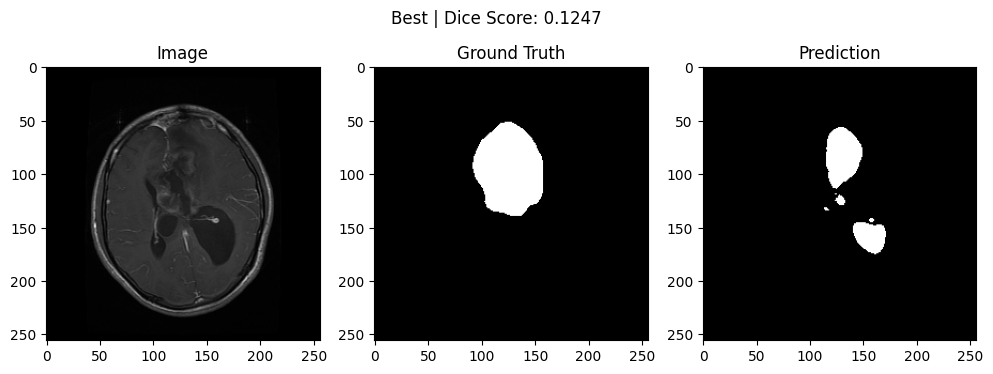

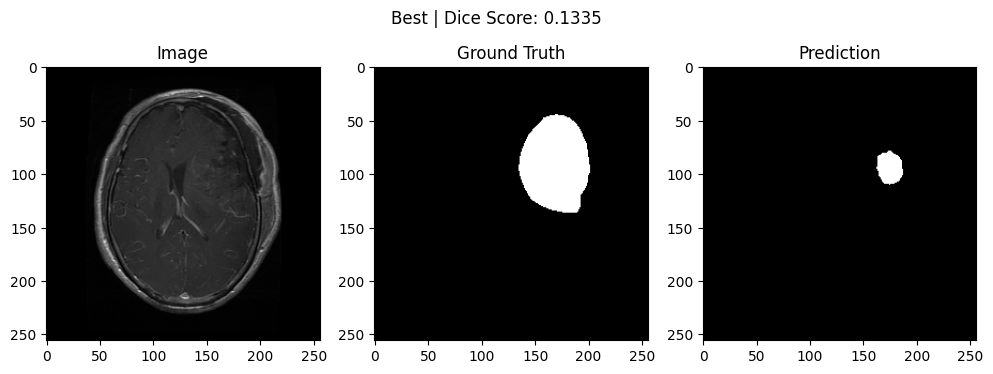

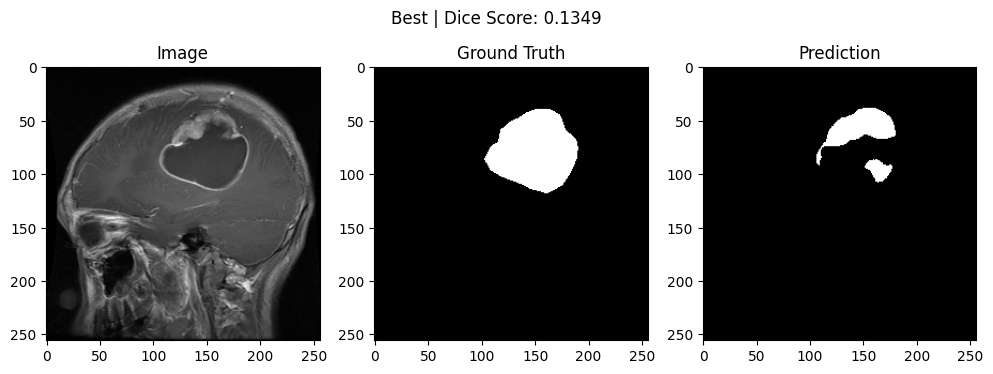

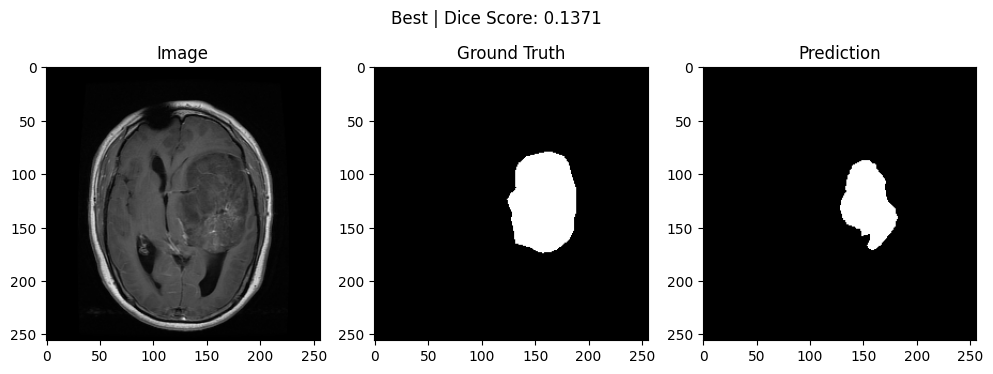

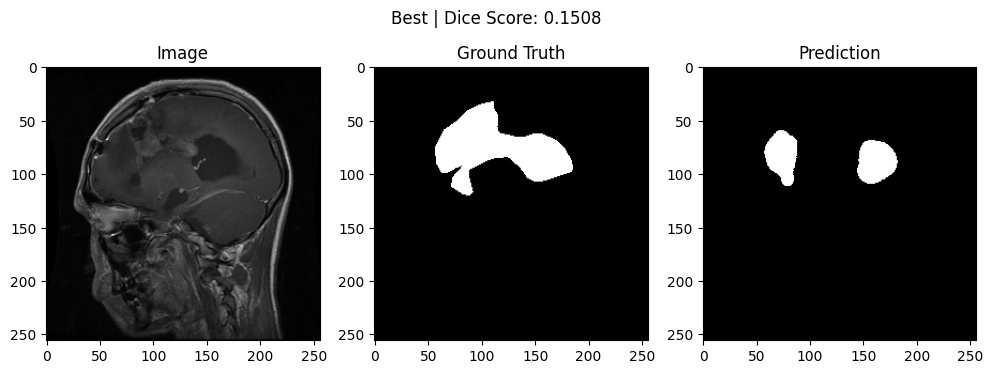

Worst 5 Predictions:


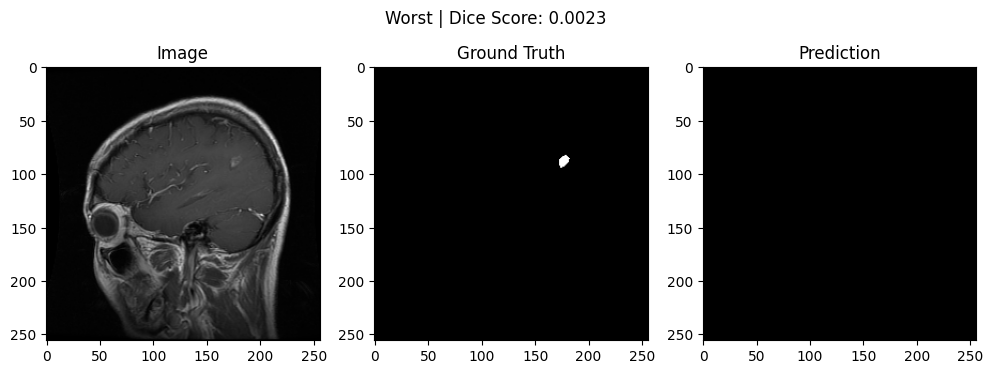

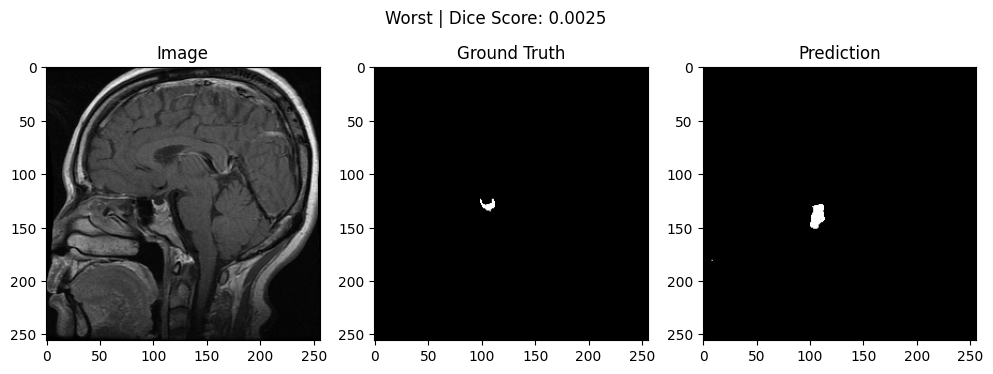

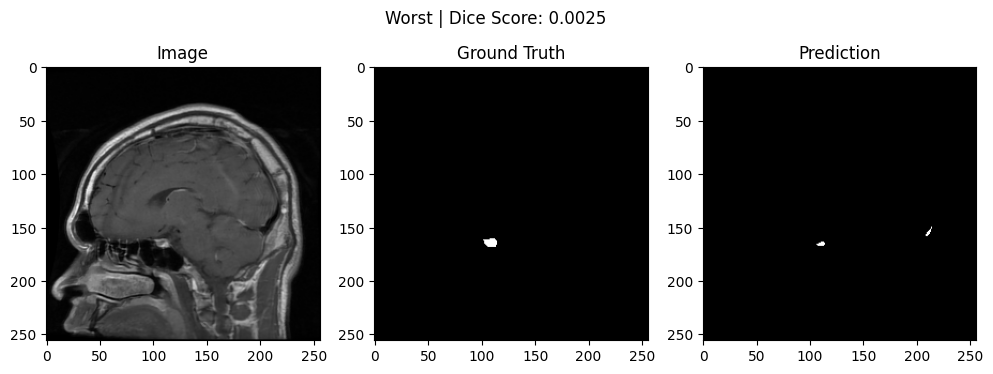

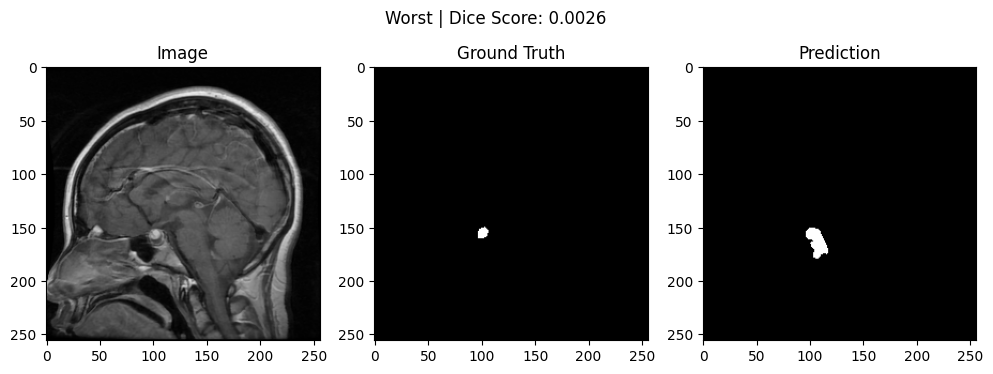

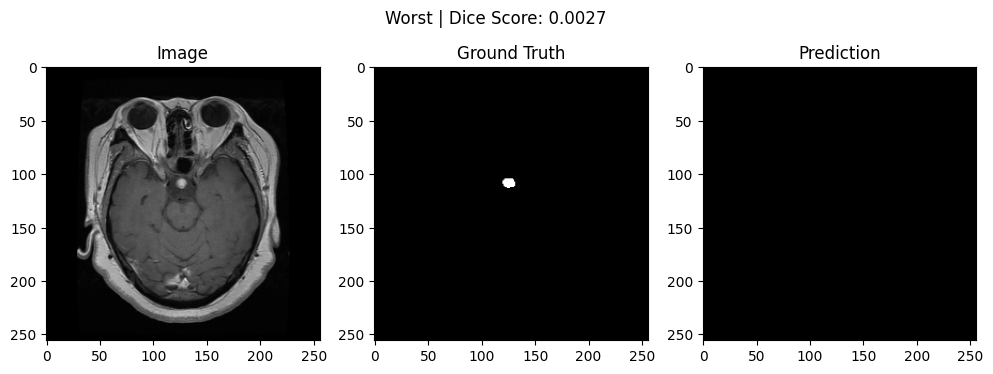

In [22]:
def show_prediction(triple, title):
    img, mask, pred = triple["image"], triple["mask"], triple["pred"]
    dice = triple["dice"]

    plt.figure(figsize=(12, 4))
    plt.suptitle(f"{title} | Dice Score: {dice:.4f}")
    plt.subplot(1, 3, 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title("Image")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth")

    plt.subplot(1, 3, 3)
    plt.imshow((pred > 0.5).squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.show()

print("Best 5 Predictions:")
for sample in results[-5:]:
    show_prediction(sample, "Best")

print("Worst 5 Predictions:")
for sample in results[:5]:
    show_prediction(sample, "Worst")


In [23]:
import numpy as np

_, mask = dataset[0]
print("Unique mask values:", np.unique(mask.numpy()))


Unique mask values: [0. 1.]
